# 02 — Real Stems vs. Proxy: When the "Confirmed" Finding Broke

### Why this notebook exists

Notebook 01 ended on an unresolved thread. The Lab 1 team measured a clean **2–3 dB
gap** between Elissa and every Suno track using the Mid/Side proxy, and a calibration
check showed the proxy's *absolute* number was off by **+7.4 dB** versus Elissa's real
stems. The whole "hypothesis CONFIRMED" conclusion survived only by assuming the proxy's
**relative ranking** across tracks was still trustworthy, even though its absolute level
wasn't. That assumption was never actually tested.

Shortly after Lab 1 wrapped, the project got something it didn't have before: **real,
AI-separated vocal and instrumental stems for every track**, not just Elissa. This
notebook rebuilds that moment — the direct measurement that finally tested the
untested assumption, and the surprise that followed.

## Setup

Same tools as Notebooks 00 and 01: `librosa`, `numpy`, `matplotlib`. This time we don't
need stereo channels or Mid/Side at all — every track now has its own `-Vocals.mp3` and
`-Instrumental.mp3` stem, so we can measure `vocal_dB - instrumental_dB` **directly**.

In [1]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt

DATA_DIR = "../data"
PLOTS_DIR = "../LABS/session_2026-07-29T172033/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

SILENCE_THRESH_DB = -40
WIN_SEC = 1.0

# (display name, stem-folder name inside data/)
TRACKS = [
    ("Elissa (reference)",  "elisa_maktooba_leek"),
    ("Ya Dar Maya (orig)",  "يا دار مية - 28-07-2026"),
    ("SONG_A",              "يا دار مية - 28-07-2026_SONG_A"),
    ("SONG_B",              "يا دار مية - 28-07-2026_SONG_B"),
    ("SONG_C",              "يا دار مية - 28-07-2026_SONG_C"),
    ("SONG_D",              "يا دار مية - 28-07-2026_SONG_D"),
]

def rms_db(x, eps=1e-10):
    '''Same loudness function from Notebooks 00 and 01 — RMS energy converted to dB.'''
    rms = np.sqrt(np.mean(x ** 2))
    return 20 * np.log10(rms + eps)

def windows(sig, sr, win_sec=WIN_SEC):
    '''Yield consecutive non-overlapping 1-second chunks of a signal.'''
    n = int(win_sec * sr)
    for i in range(0, len(sig) - n, n):
        yield sig[i:i + n]

print("Setup complete. Tracks registered:", len(TRACKS))

Setup complete. Tracks registered: 6


## A. Measuring vocal prominence directly — no more proxy

The recipe is almost identical to Notebook 01's Mid/Side proxy, but simpler: instead of
splitting one mixed signal into Mid and Side and *hoping* Mid behaves like the vocal, we
load the **real, separated** vocal and instrumental stems and subtract their loudness
directly, window by window.

$$\text{vocal\_prominence} = \text{RMS}_{dB}(\text{vocal}) - \text{RMS}_{dB}(\text{instrumental})$$

Same silence gate as before (`vocal < -40 dB` windows are dropped, since a silent vocal
frame tells us nothing about balance).

In [2]:
def load_stem_pair(track_dir):
    voc_path = f"{DATA_DIR}/{track_dir}/{track_dir}-Vocals.mp3"
    inst_path = f"{DATA_DIR}/{track_dir}/{track_dir}-Instrumental.mp3"
    voc, sr = librosa.load(voc_path, sr=22050, mono=True)
    inst, _ = librosa.load(inst_path, sr=22050, mono=True)
    return voc, inst, sr

def vocal_prominence(voc, inst, sr):
    '''Return array of (vocal_dB - instrumental_dB) over active (non-silent) 1s windows.'''
    n = min(len(voc), len(inst))
    voc, inst = voc[:n], inst[:n]
    diffs = []
    for v_win, i_win in zip(windows(voc, sr), windows(inst, sr)):
        vdb = rms_db(v_win)
        if vdb < SILENCE_THRESH_DB:
            continue
        idb = rms_db(i_win)
        diffs.append(vdb - idb)
    return np.array(diffs)

results = {}
print(f"{'Track':22s}  {'n':>4s}  {'Median':>8s}  {'Mean':>8s}  {'Std':>6s}")
print("-" * 55)
for name, track_dir in TRACKS:
    voc, inst, sr = load_stem_pair(track_dir)
    diffs = vocal_prominence(voc, inst, sr)
    results[name] = diffs
    print(f"{name:22s}  {len(diffs):4d}  {np.median(diffs):+7.2f}  {np.mean(diffs):+7.2f}  {np.std(diffs):5.2f}")

Track                      n    Median      Mean     Std
-------------------------------------------------------


Elissa (reference)       197    +3.33    +2.63   4.11


Ya Dar Maya (orig)       172    +3.29    +5.49  13.55


SONG_A                   155    +2.62    +1.91   5.13


SONG_B                   151    +3.36    +4.00   8.11


SONG_C                   177    +2.40    +1.59   6.61


SONG_D                   149    +2.17    +1.58   4.79


## B. The gap that evaporated

Here's the number that matters: Notebook 01's Mid/Side proxy showed every Suno track
sitting **2–3 dB behind** Elissa. Let's put the real, direct measurement side by side
with that proxy result.

In [3]:
proxy_gap_notebook_01 = {
    "Ya Dar Maya (orig)": -2.10,
    "SONG_A": -2.74,
    "SONG_B": -3.06,
    "SONG_C": -3.06,
    "SONG_D": -2.61,
}

elissa_med = np.median(results["Elissa (reference)"])
print(f"{'Track':22s}  {'Real gap (dB)':>14s}  {'Proxy gap (dB)':>15s}  {'Difference':>11s}")
print("-" * 68)
for name, proxy_gap in proxy_gap_notebook_01.items():
    real_gap = np.median(results[name]) - elissa_med
    print(f"{name:22s}  {real_gap:+13.2f}  {proxy_gap:+14.2f}  {real_gap - proxy_gap:+10.2f}")

Track                    Real gap (dB)   Proxy gap (dB)   Difference
--------------------------------------------------------------------
Ya Dar Maya (orig)              -0.04           -2.10       +2.06
SONG_A                          -0.71           -2.74       +2.03
SONG_B                          +0.03           -3.06       +3.09
SONG_C                          -0.92           -3.06       +2.14
SONG_D                          -1.16           -2.61       +1.45


**The ~3 dB gap has largely evaporated.** Once you measure the real vocal and real
instrumental stems directly — instead of the Mid/Side stand-in — the Suno tracks land
much closer to Elissa. SONG_B, in particular, comes out essentially *level* with Elissa,
not 3 dB behind it.

This is exactly the assumption Notebook 01 flagged and didn't test: "the proxy's absolute
number is wrong, but the relative ranking should still hold." It didn't hold. The Mid/Side
proxy wasn't just off by a constant amount — it was picking up a **different mix of
non-vocal centered content** (kick, bass, centered guitar/piano) on different tracks, in
different proportions, which distorted the ranking itself, not just the absolute level.

### Visualize it — real stems vs. the old proxy story

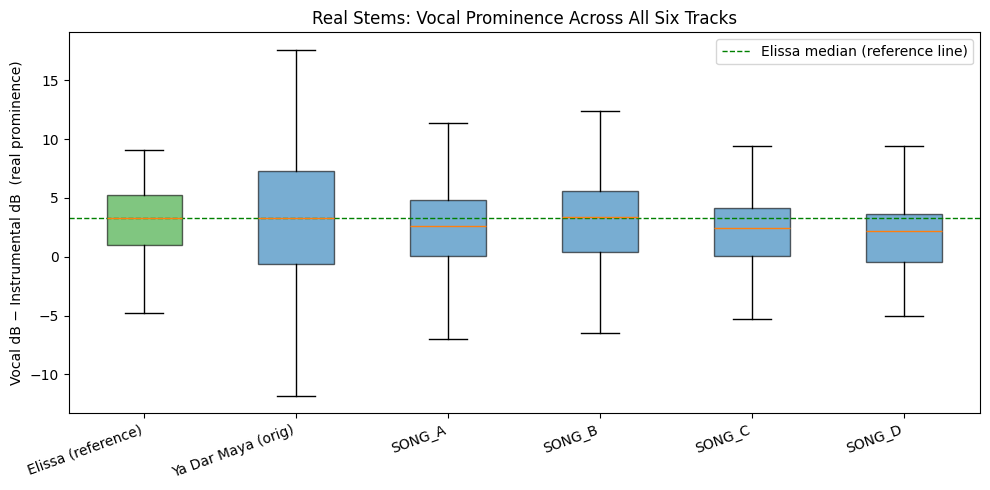

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
labels = list(results.keys())
data = [results[k] for k in labels]
bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, showfliers=False)

colors = ["#2ca02c"] + ["#1f77b4"] * (len(labels) - 1)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)

ax.set_ylabel("Vocal dB − Instrumental dB  (real prominence)")
ax.set_title("Real Stems: Vocal Prominence Across All Six Tracks")
ax.axhline(elissa_med, color="green", linestyle="--", linewidth=1,
           label="Elissa median (reference line)")
ax.legend()
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/real_stems_vocal_prominence_boxplot.png", dpi=110)
plt.show()

**Compare this box plot to Notebook 01's Mid/Side version.** The boxes sit much closer
together now, and they overlap far more than the "clean 2–3 dB gap" story suggested. If
average level isn't the real story anymore — what is?

## C. If not level, then what? Consistency

Look again at the numbers from Section A — specifically the **Std** column. Elissa's
vocal prominence barely moves from window to window. Ya Dar Maya (orig) swings wildly.
That's a different kind of gap entirely: not "the vocal is too quiet," but "the vocal's
loudness *relative to the mix* is unstable — sometimes buried, sometimes jumping out."


In [5]:
print(f"{'Track':22s}  {'Std Dev':>9s}  {'IQR':>8s}  {'Range':>8s}")
print("-" * 52)
for name, diffs in results.items():
    std = np.std(diffs)
    iqr = np.percentile(diffs, 75) - np.percentile(diffs, 25)
    rng = np.max(diffs) - np.min(diffs)
    print(f"{name:22s}  {std:8.2f}  {iqr:7.2f}  {rng:7.2f}")

Track                     Std Dev       IQR     Range
----------------------------------------------------
Elissa (reference)          4.11     4.27    31.68
Ya Dar Maya (orig)         13.55     7.95    86.41
SONG_A                      5.13     4.74    35.43
SONG_B                      8.11     5.17    51.87
SONG_C                      6.61     4.01    45.16
SONG_D                      4.79     4.14    34.06


Elissa's professionally mixed vocal sits in a tight ~4 dB band around its median.
Ya Dar Maya (orig) varies roughly **3x more**. SONG_B varies roughly **2x more**. The
average level being "correct" doesn't mean much if the vocal disappears into the mix for
several seconds at a time and then jumps back out — that's very audible, even when the
median number looks fine.

### Visualize the fluctuation itself — Elissa vs. Ya Dar Maya, window by window

A box plot hides *when* the swings happen. Let's plot the raw per-window
`vocal_dB - instrumental_dB` values in sequence for the tightest track (Elissa) and the
wildest one (Ya Dar Maya, orig), so the difference in behavior is visible directly.

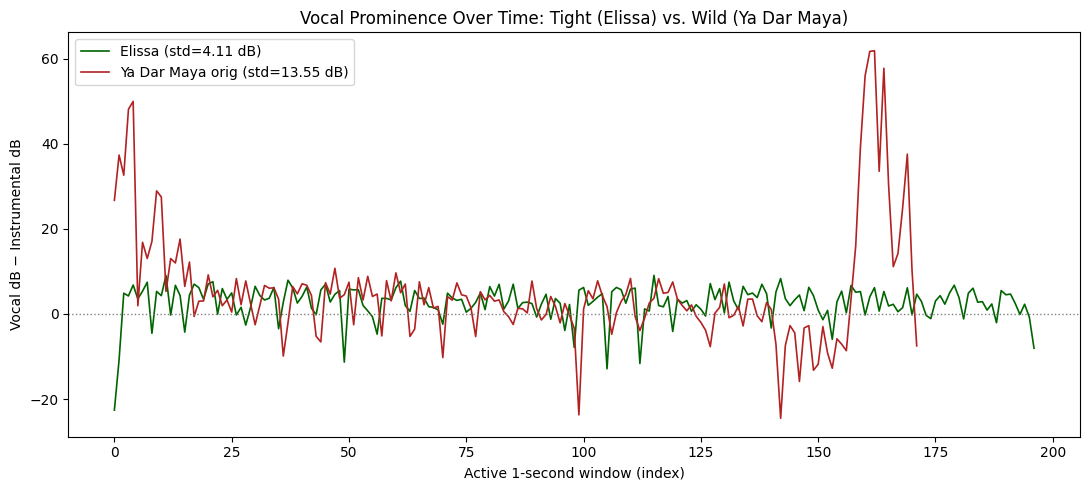

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(results["Elissa (reference)"], linewidth=1.2, color="darkgreen",
        label=f"Elissa (std={np.std(results['Elissa (reference)']):.2f} dB)")
ax.plot(results["Ya Dar Maya (orig)"], linewidth=1.2, color="firebrick",
        label=f"Ya Dar Maya orig (std={np.std(results['Ya Dar Maya (orig)']):.2f} dB)")
ax.axhline(0, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Active 1-second window (index)")
ax.set_ylabel("Vocal dB − Instrumental dB")
ax.set_title("Vocal Prominence Over Time: Tight (Elissa) vs. Wild (Ya Dar Maya)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/vocal_prominence_consistency.png", dpi=110)
plt.show()

**Elissa's line stays close to a steady band.** Ya Dar Maya's line saws up and down
across a much wider range — some windows the vocal is well above the instrumental, others
it briefly falls behind it. Same *median* balance as Elissa, very different *feel*.

## D. Revised hypothesis

| | Old hypothesis (Notebook 01) | Revised hypothesis (this notebook) |
|---|---|---|
| **Claim** | The vocal is ~2–3 dB too quiet, consistently, across all Suno tracks | The average vocal level is roughly correct; the *consistency* of that level over time is the real gap |
| **Evidence** | Mid/Side proxy, uncalibrated | Direct vocal/instrumental stem measurement, all six tracks |
| **Status** | Looked CONFIRMED, broke under real stems | Open — consistency gap is real, but *why* it happens is not yet explained |

This is a materially different problem to solve. "Turn the vocal up 3 dB" is a one-knob
fix. "Make the vocal's relative level 3x more stable throughout the track" is not — it
points toward mixing/mastering technique (compression, automation) rather than a simple
level nudge.

## E. One loose thread this notebook did *not* chase

While pulling these numbers, the spectral energy in the vocal stems looked noticeably
different between Elissa and the Suno tracks — Elissa's vocal concentrates far more
energy in the 250–500 Hz "body" range than any Suno vocal stem does. That's suspicious in
its own right: is it a genuine mixing difference, or is the separation tool doing a worse
job isolating vocals from Suno's synthetic timbre than from Elissa's natural voice? If the
*tool* behaves differently across tracks, every number in this notebook inherits that
uncertainty.

We don't have the vocabulary yet to dig into "where energy lives in frequency" properly —
that's exactly what **Notebook 03** builds. Once that's in place, **Notebook 04** comes
back to audit the separation tool itself before trusting these numbers any further.

## F. Where this leaves us

To summarize the shape of the argument this notebook just rebuilt:

1. Notebook 01 left one assumption untested: does the Mid/Side proxy's *relative ranking*
   across tracks survive, even though its *absolute* number doesn't match ground truth?
2. With real stems now available for every track, we tested it directly — and it didn't
   survive. The ~2–3 dB gap the proxy reported mostly disappears under direct measurement.
3. What's real instead is a **consistency** gap: Suno tracks (especially Ya Dar Maya orig
   and SONG_B) show 2–3x more fluctuation in vocal-instrumental balance than Elissa.
4. A new, unresolved question surfaced along the way: does the separation tool itself
   perform differently on Suno's synthetic vocals vs. Elissa's natural voice? That
   question is parked, not answered, until Notebooks 03 and 04.

**The pattern to notice across both notebooks so far:** every "confirmed" finding in this
project has come from a single analysis technique applied once. Every time a second,
more direct technique got applied, the story changed shape rather than simply confirming
the first result.

## Self-Check

Try to answer each question yourself before expanding the answer.

<details>
<summary><b>Q1.</b> In your own words, why did the Mid/Side proxy's <i>relative ranking</i> across tracks fail to hold up, even though the same proxy was applied consistently to every track?</summary>

The proxy measured "centered content vs. off-center content," not "vocal vs. instrumental."
Different tracks put different amounts of non-vocal centered material (kick, bass,
centered instruments) into their mixes, in different proportions. Applying the same
formula consistently doesn't help if what the formula is actually measuring varies from
track to track in an unknown way.
</details>

<details>
<summary><b>Q2.</b> What is the difference between "the vocal is too quiet" and "the vocal is inconsistent," and why does that distinction matter for what to do next?</summary>

"Too quiet" describes a single average number being off — the fix is a simple level
adjustment (turn the vocal up). "Inconsistent" describes the vocal's relative level
changing a lot over time even though the average is fine — turning the vocal up overall
wouldn't fix a section where it briefly disappears into the mix. Fixing inconsistency
needs different tools (like compression or manual automation), not a single gain change.
</details>

<details>
<summary><b>Q3.</b> Ya Dar Maya (orig) and Elissa can have a very similar <i>median</i> vocal prominence, and still sound different to a listener. Why doesn't the median alone capture that?</summary>

The median only describes one point in the distribution — the "typical" value — and says
nothing about how much the value varies around it. Two tracks can share the same median
while one holds a steady line and the other swings wildly above and below it. The
standard deviation, IQR, and the plotted time series each show something the median hides.
</details>

<details>
<summary><b>Q4.</b> Why does the notebook flag the spectral/separation-quality observation as a "loose thread" instead of investigating it immediately?</summary>

Properly investigating it requires understanding how energy is distributed across
frequency — a concept this notebook hasn't built yet. Chasing it here would mean
introducing an entire new toolset (FFT/STFT, frequency bands) in the middle of a
consistency-focused notebook, which is exactly the kind of "too fast" jump that produced
the flawed Notebook 01 conclusion in the first place. It's held for Notebooks 03 and 04,
in order.
</details>

## Summary — what you now have

- **Direct stem measurement**: with real vocal/instrumental stems available for every
  track, `vocal_dB − instrumental_dB` can be measured directly — no Mid/Side proxy needed.
- **The proxy's relative ranking did not survive contact with real stems**: the ~2–3 dB
  gap Notebook 01 found mostly disappears once measured directly. Average vocal level is
  roughly comparable across Elissa and the Suno tracks.
- **The real gap is consistency, not level**: Ya Dar Maya (orig) and SONG_B show 2–3x more
  fluctuation in vocal-instrumental balance over time than Elissa's steady, professional
  mix — visible both in the standard deviation and in the raw window-by-window plot.
- **A new open question, deliberately parked**: does the separation tool itself treat
  Suno's synthetic vocals differently than Elissa's natural voice? Investigated starting
  in Notebook 04, after Notebook 03 builds the frequency vocabulary needed to look at it
  properly.